___
# <font color= #8A0829> Laboratorio de Modelado de Datos </font>
- <Strong> Nombre: </Strong>  <font color="blue"> `Remi Heredia Pérez` </font>
- <Strong> Fecha </Strong>: `25/09/25`
- <Strong> Correo: </Strong>  <font color="blue"> `hector.herediap@iteso.mx` </font>
___


### <font color= #2E9AFE> Tarea 2: Análisis de Regresión Lineal</font>

La tarea consiste en ajustar un modelo de regresión lineal para predecir la variable objetivo, pero no se trata solamente de ejecutar el modelo. La tarea implica varias etapas:

1. **Cargar y explorar el conjunto de datos**
- Haz una exploración inicial al conjunto de datos
- Existen valores nulos? si los hay, justifica una estrategia para tratarlos
- Según la exploración y el significado de las variables, crees que algunas variables se puedan eliminar? De ser ser así, quítalas y sigue con tu análisis (de todos modos guarda los datos originales)
- Divide tus datos en un 80% de entrenamiento y 20% de prueba antes de realizar cualquier pre-procesamiento. **De aquí en adelante recuerda lo que vimos sobre el data leakage.**

2. **Preprocesamiento de los datos**
- Crea variables dummy para las variables categóricas (revisa que estén convertidas a tipo de dato "category" primero)
- Visualiza Variables numéricas, cómo se relacionan con tu variable a predecir (con los datos del train)
- Visualiza Variables categóricas (diagrama de caja de todas las variables categóricas antes de crear los dummies) contra la variable objetivo
- Qué observas de los gráficos anteriores? hay variables que pueden ser buenos/malos predictores?
- Revisa si hay alta correlación entre las variables
- Escala las variables predictoras (sólo las variables numéricas)
- Realiza una selección de características utilizando algún método (puedes sugerir algún método como correlación, RFE, etc.).

3. **Detección de multicolinealidad**
- Calcula el VIF (Variance Inflation Factor) para detectar multicolinealidad entre las variables independientes (esto no lo vimos, pero te pido buscar la interpretación del VIF en internet). Puedes basarte en este código:


In [42]:
'''
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['Features'] = X_train_seleccionadas.columns
vif['VIF'] = [variance_inflation_factor(X_train_seleccionadas.values, i) for i in range(X_train_seleccionadas.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by = "VIF", ascending = False)
vif
'''

'\nfrom statsmodels.stats.outliers_influence import variance_inflation_factor\n\nvif = pd.DataFrame()\nvif[\'Features\'] = X_train_seleccionadas.columns\nvif[\'VIF\'] = [variance_inflation_factor(X_train_seleccionadas.values, i) for i in range(X_train_seleccionadas.shape[1])]\nvif[\'VIF\'] = round(vif[\'VIF\'], 2)\nvif = vif.sort_values(by = "VIF", ascending = False)\nvif\n'

- Si detectas multicolinealidad, realiza la eliminación de variables y justifica por qué las variables eliminadas son redundantes.

4. **Entrenamiento y validación del modelo**

- Entrena el modelo utilizando regresión lineal y evalúa su rendimiento en el conjunto de entrenamiento y prueba.
- Implementa cross-validation y reporta las métricas promedio (RMSE, MAE, R²).
- Visualiza la curva de aprendizaje
- El modelo está haciendo overfittint/underfitting?
  
5. **Interpretación de los coeficientes**

*NOTA: Esto no lo vimos en clase, por lo tanto te tocará investigar cómo interpretar los coeficientes. Interpretar los coeficientes es de suma importancia para poder explicar tu modelo*

- Interpreta los coeficientes del modelo final (model.coef_) y discute cuáles son las variables más importantes para predecir la variable objetivo.
- ¿Cómo afectan los signos y magnitudes de los coeficientes a la interpretación del modelo?

6. **Mejora del modelo**

- Si el modelo presenta un mal ajuste, propón al menos formas de mejorarlo.
- Evalúa si las mejoras introducidas realmente generan un mejor desempeño del modelo.

7. **Verificación de las suposiciones del modelo**

- Revisa los residuales se distribuyen normalmente con media cero.
- Existió relación lineal entre las X y Y?
- Con tu modelo final, existe multicolinealidad en tus variables independientes?


# Renta de bicicletas

Este conjunto de datos contiene recuentos diarios de bicicletas rentadas de una empresa en Washington, D.C.

Se tienen las siguientes variables:
- Conteo de bicicletas rentadas --> target (cnt).
- Fecha (dteday)
- La temporada. Ya sea primavera, verano, otoño o invierno (season).
- Year (yr)
- Mes (mnth)
- Hora (hr)
- Indicador de si el día era festivo o no (holiday).
- Día de la semana (weekday)
- Indicador de si el día fue entre semana o fin de semana (workingday).
- La situación meteorológica ese día. 1=despejado, 2=Pocas nubes, 3=Parcialmente nublado, 4=Nublado (weathersit).
- Temperatura en grados Celsius (temp).
- Temperatura normalizada en Celsius. Los valores estan calculaods como (t-tmin)/(tmax-tmin), tmin=-16, t_max=+50 (atemp)
- Humedad relativa en porcentaje (hum).
- Velocidad del viento en km por hora (windspeed).


In [43]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from ucimlrepo import fetch_ucirepo 
  
#datos 
bike_sharing = fetch_ucirepo(id=275) 
 
X = bike_sharing.data.features 
y = bike_sharing.data.targets 

df = pd.concat([X,y], axis=1)
df.head()

,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,16
1,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,40
2,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,32
3,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,13
4,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,1


In [44]:
# ============================================
# Proyecto: Regresión lineal - Renta de bicicletas (UCI)
# ============================================

# ---- 0. Imports
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split, cross_val_score, KFold, learning_curve
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.feature_selection import RFE

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [45]:
# ---- 1. Cargar datos
bike_sharing = fetch_ucirepo(id=275)  # UCI Bike Sharing
X = bike_sharing.data.features
y = bike_sharing.data.targets

# Unir features + target para EDA
df = pd.concat([X, y], axis=1).copy()

# Asegurar nombres en minúsculas por consistencia
df.columns = [c.lower() for c in df.columns]

print("Shape del dataframe:", df.shape)
print(df.head(3))
print("\nColumnas:", df.columns.tolist())

Shape del dataframe: (17379, 14)
       dteday  season  yr  mnth  hr  holiday  weekday  workingday  weathersit  \
0  2011-01-01       1   0     1   0        0        6           0           1   
1  2011-01-01       1   0     1   1        0        6           0           1   
2  2011-01-01       1   0     1   2        0        6           0           1   

   temp   atemp   hum  windspeed  cnt  
0  0.24  0.2879  0.81        0.0   16  
1  0.22  0.2727  0.80        0.0   40  
2  0.22  0.2727  0.80        0.0   32  

Columnas: ['dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'cnt']


In [46]:
# ---- 1.a Exploración inicial
print("\n--- Info() ---")
print(df.info())

print("\n--- Descripción numérica ---")
print(df.describe().T)

print("\n--- % de valores nulos por columna ---")
null_pct = df.isna().mean().sort_values(ascending=False)
print(null_pct)

# Estrategia de nulos:
# Si existieran nulos en numéricas: imputar con mediana.
# Si existieran nulos en categóricas: imputar con categoría 'Missing'.
# En este dataset típicamente no hay nulos, pero dejamos la lógica preparada abajo.

# ---- 1.b Posible eliminación de variables
# Regla: eliminar identificadores, duplicados de información o variables con fuga de información
# (por ejemplo, si hubiera una variable que es suma de otras post-target).
# En Bike Sharing, 'instant' (id) si aparece, se elimina. 'dteday' (fecha) puede usarse para extraer señales,
# pero como tenemos mnth, weekday, season y (en hora.csv) 'hr', la fecha cruda puede eliminarse para evitar colinealidad.
cand_to_drop = [c for c in ['instant', 'dteday', 'casual', 'registered'] if c in df.columns]
# Nota: 'casual' y 'registered' suman 'cnt' (fuga de información del target si se usaran como predictores), por eso se eliminan.
df_original = df.copy()
df = df.drop(columns=cand_to_drop, errors='ignore')
print("\nEliminando columnas potencialmente problemáticas (si existían):", cand_to_drop)
print("Shape tras eliminación:", df.shape)


--- Info() ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 14 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   dteday      17379 non-null  object 
 1   season      17379 non-null  int64  
 2   yr          17379 non-null  int64  
 3   mnth        17379 non-null  int64  
 4   hr          17379 non-null  int64  
 5   holiday     17379 non-null  int64  
 6   weekday     17379 non-null  int64  
 7   workingday  17379 non-null  int64  
 8   weathersit  17379 non-null  int64  
 9   temp        17379 non-null  float64
 10  atemp       17379 non-null  float64
 11  hum         17379 non-null  float64
 12  windspeed   17379 non-null  float64
 13  cnt         17379 non-null  int64  
dtypes: float64(4), int64(9), object(1)
memory usage: 1.9+ MB
None

--- Descripción numérica ---
              count        mean         std   min      25%       50%  \
season      17379.0    2.501640    1.106918  1.00 

In [47]:
# ---- 1.c Definir target y features
# Nombre típico del target en este dataset: 'cnt'
target_col = 'cnt'
assert target_col in df.columns, "No encuentro la columna 'cnt' como target."

X = df.drop(columns=[target_col])
y = df[target_col].astype(float)

In [48]:
# ---- 1.d División Train/Test (antes de cualquier preprocesamiento) 80/20
# Para evitar data leakage, todo lo que sigue se ajusta SOLO con train, y se aplica a test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42
)

print("\nShapes -> X_train:", X_train.shape, "| X_test:", X_test.shape)


Shapes -> X_train: (13903, 12) | X_test: (3476, 12)


In [49]:
# ---- 2. Preprocesamiento
# 2.1 Detectar tipos: categóricas vs numéricas
# Convertimos a 'category' algunas que semánticamente lo son si están presentes.
possible_cats = ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
for c in possible_cats:
    if c in X_train.columns:
        X_train[c] = X_train[c].astype('category')
        X_test[c]  = X_test[c].astype('category')

# Separar listas de columnas
cat_cols = [c for c in X_train.columns if str(X_train[c].dtype) == 'category']
num_cols = [c for c in X_train.columns if c not in cat_cols]

print("\nCategóricas:", cat_cols)
print("Numéricas:", num_cols)


Categóricas: ['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit']
Numéricas: ['temp', 'atemp', 'hum', 'windspeed']


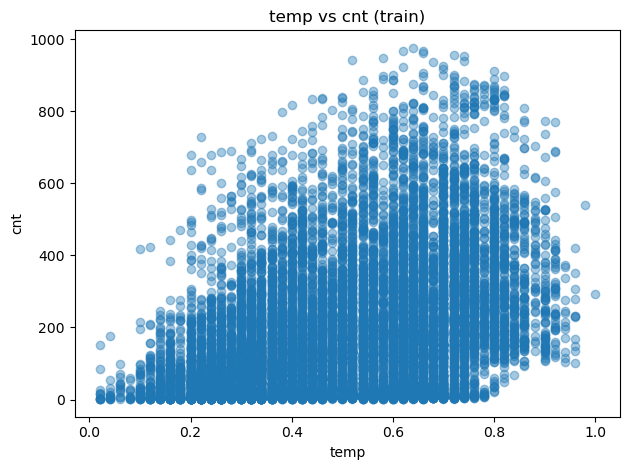

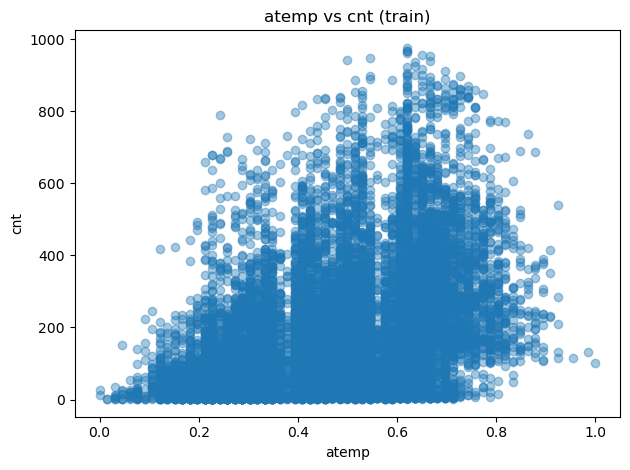

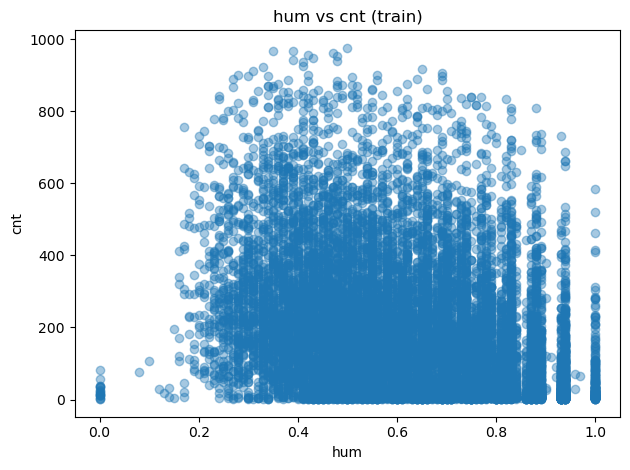

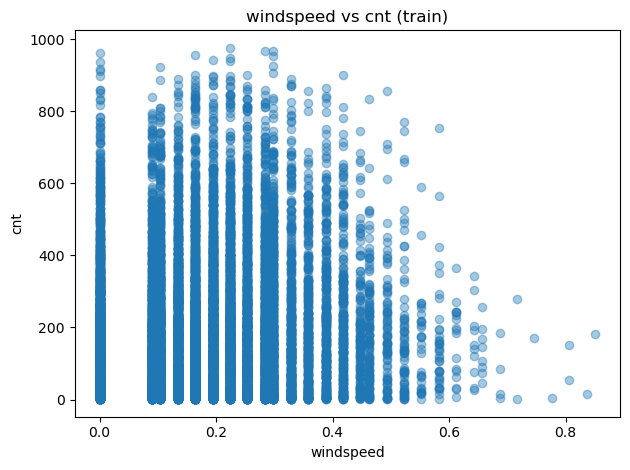

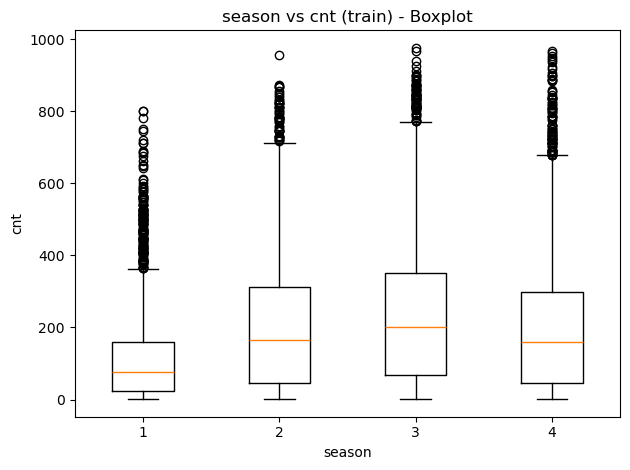

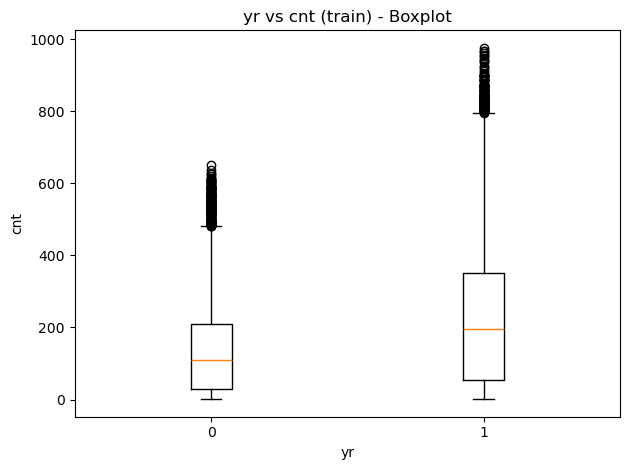

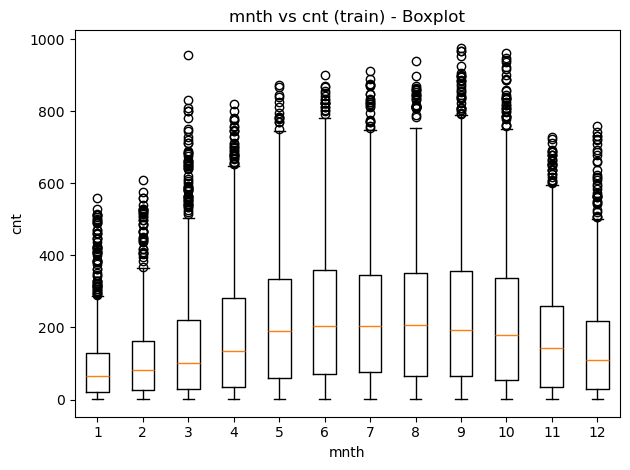

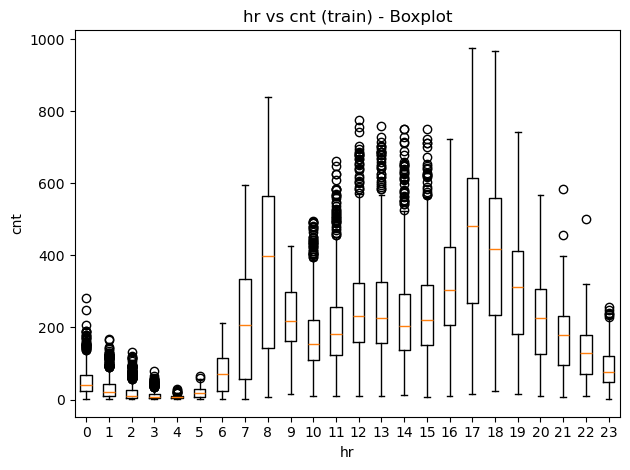

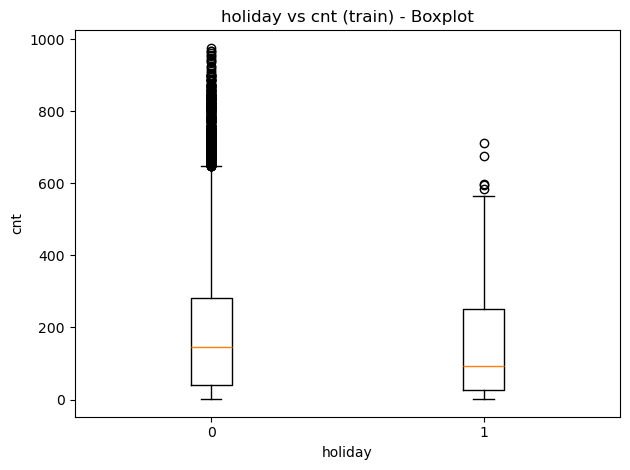

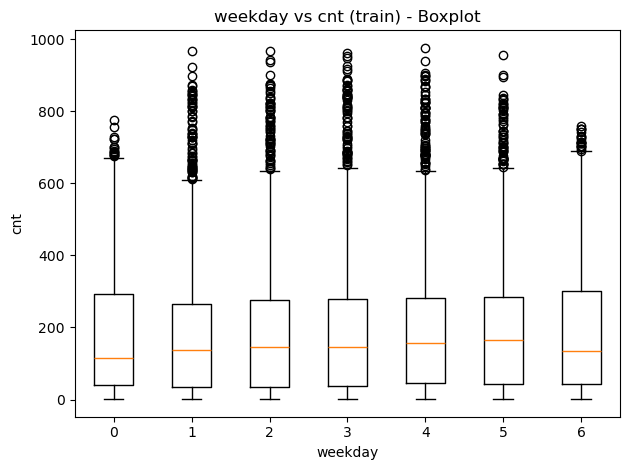

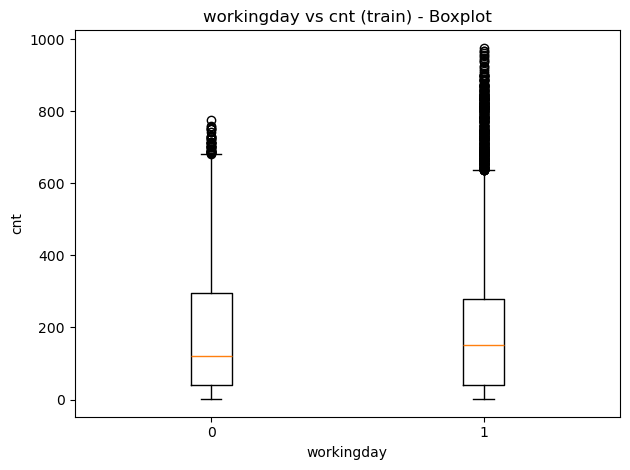

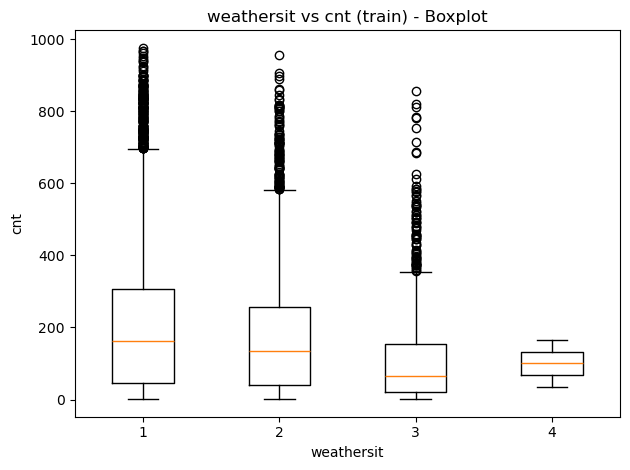

In [50]:
# 2.2 Visualizaciones (usando SOLO train)
# Numéricas vs y (scatter)
for c in num_cols:
    plt.figure()
    plt.scatter(X_train[c], y_train, alpha=0.4)
    plt.title(f"{c} vs cnt (train)")
    plt.xlabel(c)
    plt.ylabel("cnt")
    plt.tight_layout()
    plt.show()

# Categóricas vs y (boxplots)
for c in cat_cols:
    plt.figure()
    # construir listas por categoría
    groups = [y_train[X_train[c] == k] for k in X_train[c].cat.categories]
    plt.boxplot(groups, labels=X_train[c].cat.categories)
    plt.title(f"{c} vs cnt (train) - Boxplot")
    plt.xlabel(c)
    plt.ylabel("cnt")
    plt.tight_layout()
    plt.show()

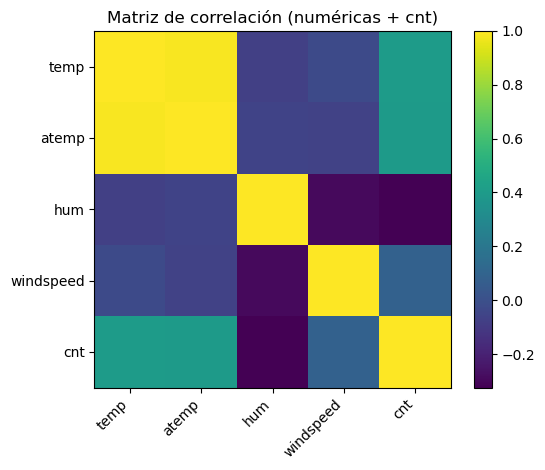

In [51]:
# 2.3 Correlación entre numéricas (heatmap simple sin seaborn)
if len(num_cols) > 1:
    corr = X_train[num_cols].assign(cnt=y_train).corr()
    plt.figure()
    im = plt.imshow(corr, interpolation='nearest')
    plt.title("Matriz de correlación (numéricas + cnt)")
    plt.colorbar(im, fraction=0.046, pad=0.04)
    ticks = range(len(corr.columns))
    plt.xticks(ticks, corr.columns, rotation=45, ha='right')
    plt.yticks(ticks, corr.index)
    plt.tight_layout()
    plt.show()

# Observaciones (texto):
# - Revisa visualmente si variables como temperatura (temp, atemp), humedad (hum) y viento (windspeed)
#   parecen correlacionadas con cnt; típicamente temp/atemp se correlacionan positivamente,
#   y hum/viento pueden afectar negativamente.
# - En categóricas, season, weathersit, hr (si existe) y workingday suelen mostrar diferencias claras.

In [52]:
# ---- 2.4 Pipeline de preprocesamiento: dummies y escalado de numéricas  (REEMPLAZA el bloque 2.4 original)

# Compatibilidad OHE:
# - sklearn>=1.2 usa 'sparse_output=False'
# - sklearn<1.2 usa 'sparse=False'
try:
    ohe = OneHotEncoder(handle_unknown='ignore', drop=None, sparse_output=False)
except TypeError:
    ohe = OneHotEncoder(handle_unknown='ignore', drop=None, sparse=False)

scaler = StandardScaler()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat', ohe,   cat_cols)
    ],
    remainder='drop'
)

# Ajustar SOLO con train y transformar
X_train_pp = preprocessor.fit_transform(X_train)
X_test_pp  = preprocessor.transform(X_test)

# Obtener nombres de columnas tras el preprocesamiento (con fallback para versiones viejas)
num_features_out = num_cols
cat_feature_names = []
if len(cat_cols) > 0:
    try:
        cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names_out(cat_cols).tolist()
    except AttributeError:
        # sklearn<1.0
        cat_feature_names = preprocessor.named_transformers_['cat'].get_feature_names(cat_cols).tolist()

feature_names_pp = num_features_out + cat_feature_names
print("\n# de features tras preprocesamiento:", len(feature_names_pp))



# de features tras preprocesamiento: 61


In [53]:
# 2.5 Selección de características (ejemplo: RFE con Regresión Lineal)
base_estimator = LinearRegression()
# Selecciona como mínimo 10 o hasta 60% de las features, lo que sea mayor
n_features_to_select = max(10, int(0.6 * X_train_pp.shape[1]))
selector = RFE(estimator=base_estimator, n_features_to_select=n_features_to_select, step=1)
selector.fit(X_train_pp, y_train)

selected_mask = selector.support_
selected_features = [f for f, keep in zip(feature_names_pp, selected_mask) if keep]

print("\nCaracterísticas seleccionadas (RFE):", len(selected_features))
print(selected_features[:25], "..." if len(selected_features) > 25 else "")

X_train_sel = X_train_pp[:, selected_mask]
X_test_sel  = X_test_pp[:, selected_mask]


Características seleccionadas (RFE): 36
['temp', 'atemp', 'season_1', 'season_4', 'yr_0', 'yr_1', 'mnth_7', 'mnth_11', 'mnth_12', 'hr_0', 'hr_1', 'hr_2', 'hr_3', 'hr_4', 'hr_5', 'hr_6', 'hr_7', 'hr_8', 'hr_9', 'hr_10', 'hr_12', 'hr_13', 'hr_14', 'hr_15', 'hr_16'] ...


In [54]:
# ---- 3. Multicolinealidad (VIF) sobre las variables seleccionadas
# Nota: VIF > 5 o > 10 se suele considerar preocupante (criterios comunes).
vif_df = pd.DataFrame()
vif_df['feature'] = selected_features
vif_df['VIF'] = [variance_inflation_factor(X_train_sel, i) for i in range(X_train_sel.shape[1])]
vif_df = vif_df.sort_values('VIF', ascending=False)
print("\n--- Tabla VIF (variables seleccionadas) ---")
print(vif_df.head(20))


--- Tabla VIF (variables seleccionadas) ---
         feature        VIF
0           temp  42.559148
1          atemp  40.532429
5           yr_1  19.893039
4           yr_0  19.309602
33  weathersit_1   3.171398
34  weathersit_2   3.161760
2       season_1   2.458714
3       season_4   2.124140
24         hr_16   1.950394
14          hr_5   1.949312
11          hr_2   1.947912
21         hr_13   1.946404
25         hr_17   1.942347
17          hr_8   1.941648
30         hr_22   1.938381
10          hr_1   1.937665
20         hr_12   1.934846
15          hr_6   1.934111
31         hr_23   1.933469
18          hr_9   1.932003


In [55]:
# Eliminación iterativa si hay VIF muy altos (opcional y transparente)
# Aquí aplicamos una regla simple: mientras exista VIF>10, eliminar la mayor VIF y recalcular.
X_sel = X_train_sel.copy()
features_sel = selected_features.copy()

def compute_vif(X_mat, names):
    vif_local = pd.DataFrame({'feature': names})
    vif_local['VIF'] = [variance_inflation_factor(X_mat, i) for i in range(X_mat.shape[1])]
    return vif_local.sort_values('VIF', ascending=False)

In [56]:
threshold_vif = 10.0
changed = True
while changed and X_sel.shape[1] > 2:
    vif_now = compute_vif(X_sel, features_sel)
    if vif_now['VIF'].iloc[0] > threshold_vif:
        drop_feat = vif_now['feature'].iloc[0]
        idx = features_sel.index(drop_feat)
        # eliminar columna con mayor VIF
        X_sel = np.delete(X_sel, idx, axis=1)
        features_sel.pop(idx)
        print(f"Eliminando por alta multicolinealidad: {drop_feat} (VIF={vif_now['VIF'].iloc[0]:.2f})")
    else:
        changed = False

Eliminando por alta multicolinealidad: temp (VIF=42.56)
Eliminando por alta multicolinealidad: yr_1 (VIF=19.78)


In [57]:
# Construct test matrix with the same final selected features (map by name)
# Creamos un índice de columnas finales dentro de feature_names_pp
final_mask = np.array([name in features_sel for name in feature_names_pp])
X_train_final = X_train_pp[:, final_mask]
X_test_final  = X_test_pp[:,  final_mask]
final_features = [f for f, keep in zip(feature_names_pp, final_mask) if keep]

print("\n# de features finales tras control VIF:", len(final_features))


# de features finales tras control VIF: 34


In [58]:
# ---- 4. Entrenamiento y validación  (MANTIENE tu linreg.fit)
linreg = LinearRegression()
linreg.fit(X_train_final, y_train)

# ---- 4.b Función de métricas (COMPAT)  (REEMPLAZA tu función 'metrics' + llamadas inmediatas)
def metrics(y_true, y_pred, label=""):
    # mean_squared_error sin 'squared=' para compatibilidad con sklearn antiguos
    mse  = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    print(f"{label} -> RMSE: {rmse:.3f} | MAE: {mae:.3f} | R2: {r2:.3f}")
    return rmse, mae, r2

# Predicciones y métricas holdout
y_pred_train = linreg.predict(X_train_final)
y_pred_test  = linreg.predict(X_test_final)

print("\n--- Métricas (holdout) ---")
m_train = metrics(y_train, y_pred_train, "Train")
m_test  = metrics(y_test,  y_pred_test,  "Test")



--- Métricas (holdout) ---
Train -> RMSE: 102.967 | MAE: 76.072 | R2: 0.681
Test -> RMSE: 101.412 | MAE: 74.400 | R2: 0.675


In [59]:
# ---- 4.c Cross-Validation (6-fold) - COMPAT  (REEMPLAZA tu bloque de cross_val_score)
cv = KFold(n_splits=6, shuffle=True, random_state=42)

# Usamos neg_mean_squared_error y luego sacamos raíz para RMSE
mse_scores = -cross_val_score(linreg, X_train_final, y_train,
                              scoring="neg_mean_squared_error", cv=cv)
rmse_scores = np.sqrt(mse_scores)

mae_scores  = -cross_val_score(linreg, X_train_final, y_train,
                               scoring="neg_mean_absolute_error", cv=cv)
r2_scores   =  cross_val_score(linreg, X_train_final, y_train,
                               scoring="r2", cv=cv)

print("\n--- Cross-Validation (6-fold) - Promedios y ±std ---")
print(f"RMSE_cv: {rmse_scores.mean():.3f} ± {rmse_scores.std():.3f}")
print(f"MAE_cv:  {mae_scores.mean():.3f} ± {mae_scores.std():.3f}")
print(f"R2_cv:   {r2_scores.mean():.3f} ± {r2_scores.std():.3f}")



--- Cross-Validation (6-fold) - Promedios y ±std ---
RMSE_cv: 103.192 ± 3.017
MAE_cv:  76.278 ± 2.233
R2_cv:   0.679 ± 0.015


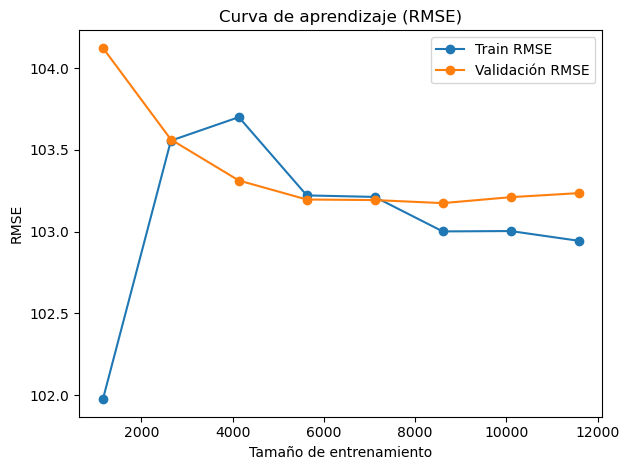

In [60]:
# ---- 4.d Curva de aprendizaje (RMSE) - COMPAT  (REEMPLAZA tu bloque de learning_curve)
train_sizes, train_scores, val_scores = learning_curve(
    linreg,
    X_train_final, y_train,
    cv=cv,
    scoring="neg_mean_squared_error",   # en vez de neg_root_mean_squared_error
    train_sizes=np.linspace(0.1, 1.0, 8),
    shuffle=True                        # 'random_state' puede no existir en versiones viejas
)

train_rmse = np.sqrt(-train_scores.mean(axis=1))
val_rmse   = np.sqrt(-val_scores.mean(axis=1))

plt.figure()
plt.plot(train_sizes, train_rmse, marker='o', label='Train RMSE')
plt.plot(train_sizes, val_rmse, marker='o', label='Validación RMSE')
plt.title("Curva de aprendizaje (RMSE)")
plt.xlabel("Tamaño de entrenamiento")
plt.ylabel("RMSE")
plt.legend()
plt.tight_layout()
plt.show()


In [61]:
# ---- 5. Interpretación de coeficientes
# Nota importante:
#   - Las variables numéricas están estandarizadas (media 0, var 1),
#     por lo que el coeficiente indica el cambio promedio en 'cnt'
#     por un incremento de 1 desviación estándar en esa variable.
#   - Para dummies, el coeficiente es la diferencia promedio frente a la categoría base (que no aparece explícita).
coefs = pd.Series(linreg.coef_, index=final_features).sort_values(key=abs, ascending=False)
print("\n--- Top 20 coeficientes por magnitud (escala estandarizada) ---")
print(coefs.head(20))

# Señalar variables más influyentes (signo y magnitud)
print("\nInterpretación breve:")
for name, val in coefs.head(10).items():
    direction = "aumenta" if val > 0 else "disminuye"
    print(f"- {name}: un aumento de 1 desviación estándar en esta característica {direction} el conteo esperado de rentas en ~{abs(val):.2f} bicis (ceteris paribus).")


--- Top 20 coeficientes por magnitud (escala estandarizada) ---
hr_17           253.212658
hr_18           211.412284
hr_4           -186.745540
hr_3           -182.854112
hr_8            172.120249
hr_2           -172.003053
hr_5           -168.872940
hr_1           -160.798389
hr_0           -143.229730
hr_6           -111.484113
hr_23          -108.067025
hr_19           101.572576
hr_16            97.232427
yr_0            -88.484046
weathersit_4    -86.634069
weathersit_1     84.426016
hr_22           -68.706140
weathersit_2     64.481513
hr_12            45.754473
hr_13            42.781886
dtype: float64

Interpretación breve:
- hr_17: un aumento de 1 desviación estándar en esta característica aumenta el conteo esperado de rentas en ~253.21 bicis (ceteris paribus).
- hr_18: un aumento de 1 desviación estándar en esta característica aumenta el conteo esperado de rentas en ~211.41 bicis (ceteris paribus).
- hr_4: un aumento de 1 desviación estándar en esta característica disminuy

In [62]:
# ---- 6. Mejora del modelo (ideas)
# (a) Probar regularización (Ridge/Lasso/ElasticNet) para manejar multicolinealidad y reducir varianza.
# (b) Interacciones no lineales: polinomios de grado bajo en numéricas (ej. temp^2) si la relación no es estrictamente lineal.
# (c) Agregar features de calendario (si mantuviéramos dteday): festivos específicos, mes-año, etc.
# (d) Si se usa el dataset horario, interacciones (hr x workingday) o (hr x season).
# (e) Revisión de outliers y transformaciones (log(cnt+1)) si la distribución de cnt es sesgada.

# Ejemplo rápido de Ridge (para comparar sin desbordar el flujo principal):
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10.0)  # sin random_state (no todas las versiones lo aceptan)
ridge.fit(X_train_final, y_train)
y_pred_ridge = ridge.predict(X_test_final)
print("\nRidge (alpha=10) - Test:")
_ = metrics(y_test, y_pred_ridge, "Ridge Test")


Ridge (alpha=10) - Test:
Ridge Test -> RMSE: 101.374 | MAE: 74.327 | R2: 0.675


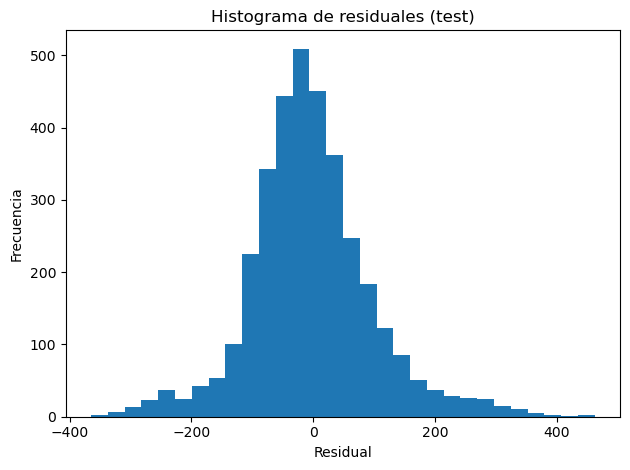


Media de residuales (test): -4.0176753732562736


In [63]:
# ---- 7. Verificación de supuestos del modelo
# 7.1 Residuales ~ N(0, sigma^2) y media ~ 0
res_train = y_train - y_pred_train
res_test  = y_test  - y_pred_test

plt.figure()
plt.hist(res_test, bins=30)
plt.title("Histograma de residuales (test)")
plt.xlabel("Residual")
plt.ylabel("Frecuencia")
plt.tight_layout()
plt.show()

print("\nMedia de residuales (test):", np.mean(res_test))

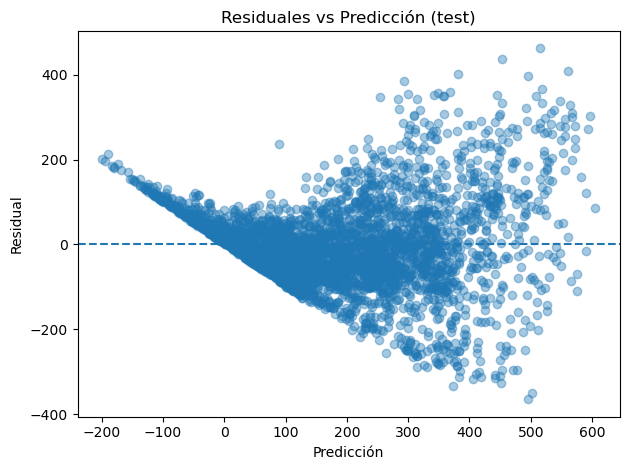

In [64]:
# 7.2 Relación lineal X-Y: revisar residuales vs predicción (no debería verse patrón)
plt.figure()
plt.scatter(y_pred_test, res_test, alpha=0.4)
plt.axhline(0, linestyle='--')
plt.title("Residuales vs Predicción (test)")
plt.xlabel("Predicción")
plt.ylabel("Residual")
plt.tight_layout()
plt.show()

In [65]:
# 7.3 Multicolinealidad final (VIF) en el conjunto final de variables
vif_final = pd.DataFrame()
vif_final['feature'] = final_features
vif_final['VIF'] = [variance_inflation_factor(X_train_final, i) for i in range(X_train_final.shape[1])]
vif_final = vif_final.sort_values('VIF', ascending=False)
print("\n--- VIF final (modelo entrenado) ---")
print(vif_final.head(20))


--- VIF final (modelo entrenado) ---
         feature       VIF
31  weathersit_1  6.625607
32  weathersit_2  3.192414
1       season_1  3.020811
0          atemp  2.737450
2       season_4  2.683011
3           yr_0  1.933350
5        mnth_11  1.763707
6        mnth_12  1.421941
19         hr_13  1.400216
21         hr_15  1.395192
18         hr_12  1.394360
22         hr_16  1.394089
20         hr_14  1.386940
23         hr_17  1.382476
25         hr_19  1.380104
17         hr_10  1.378660
12          hr_5  1.373806
9           hr_2  1.373344
26         hr_20  1.371236
28         hr_22  1.370647


In [66]:
# ---- Reporte final breve
print("\n================= RESUMEN =================")
print(f"Train -> RMSE: {m_train[0]:.3f} | MAE: {m_train[1]:.3f} | R2: {m_train[2]:.3f}")
print(f"Test  -> RMSE: {m_test[0]:.3f}  | MAE: {m_test[1]:.3f}  | R2: {m_test[2]:.3f}")
print("CV(5) -> RMSE:", f"{rmse_scores.mean():.3f}±{rmse_scores.std():.3f}",
      "| MAE:", f"{mae_scores.mean():.3f}±{mae_scores.std():.3f}",
      "| R2:",  f"{r2_scores.mean():.3f}±{r2_scores.std():.3f}")
print("Nº features finales:", len(final_features))
print("Ejemplos de variables más influyentes (por |coef| estandarizado):")
print(coefs.head(10))
print("===========================================")


================= RESUMEN =================
Train -> RMSE: 102.967 | MAE: 76.072 | R2: 0.681
Test  -> RMSE: 101.412  | MAE: 74.400  | R2: 0.675
CV(5) -> RMSE: 103.192±3.017 | MAE: 76.278±2.233 | R2: 0.679±0.015
Nº features finales: 34
Ejemplos de variables más influyentes (por |coef| estandarizado):
hr_17    253.212658
hr_18    211.412284
hr_4    -186.745540
hr_3    -182.854112
hr_8     172.120249
hr_2    -172.003053
hr_5    -168.872940
hr_1    -160.798389
hr_0    -143.229730
hr_6    -111.484113
dtype: float64
